#**How to Train YOLO11 Object Detection Model on a Custom Dataset**

Data: https://universe.roboflow.com/bhavish511/fyp_images

In [1]:
!nvidia-smi

Mon May 26 09:20:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Step 01 # Install the Ultralytics Package**

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

**Step 02 # Import All the Requried Libraries**

In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.145 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.8/112.6 GB disk)


In [6]:
from ultralytics import YOLO
from IPython.display import Image

**Step # 03 Download Dataset from Roboflow**

In [7]:
import zipfile
import os

# Path to your uploaded zip file (auto path from Colab left panel)
zip_path = "/content/American Sign Language Letters.v1-v1.yolov11.zip"
extract_dir = "/content/asl_dataset"  # You can change the folder name

# Unzipping
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Check extracted contents
print("Extracted files to:", extract_dir)
os.listdir(extract_dir)

Extracted files to: /content/asl_dataset


['data.yaml',
 'test',
 'train',
 'valid',
 'README.roboflow.txt',
 'README.dataset.txt']

In [9]:
dataset_location = extract_dir
print(dataset_location)

/content/asl_dataset


**Step # 04 Train YOLO11 Model on a Custom Dataset**

In [10]:
!yolo task=detect mode=train data={dataset_location}/data.yaml model="yolo11n.pt" epochs=100 imgsz=640

100% 5.35M/5.35M [00:00<00:00, 269MB/s]
Ultralytics 8.3.145 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/asl_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

**Step # 05 Examine Training Results**

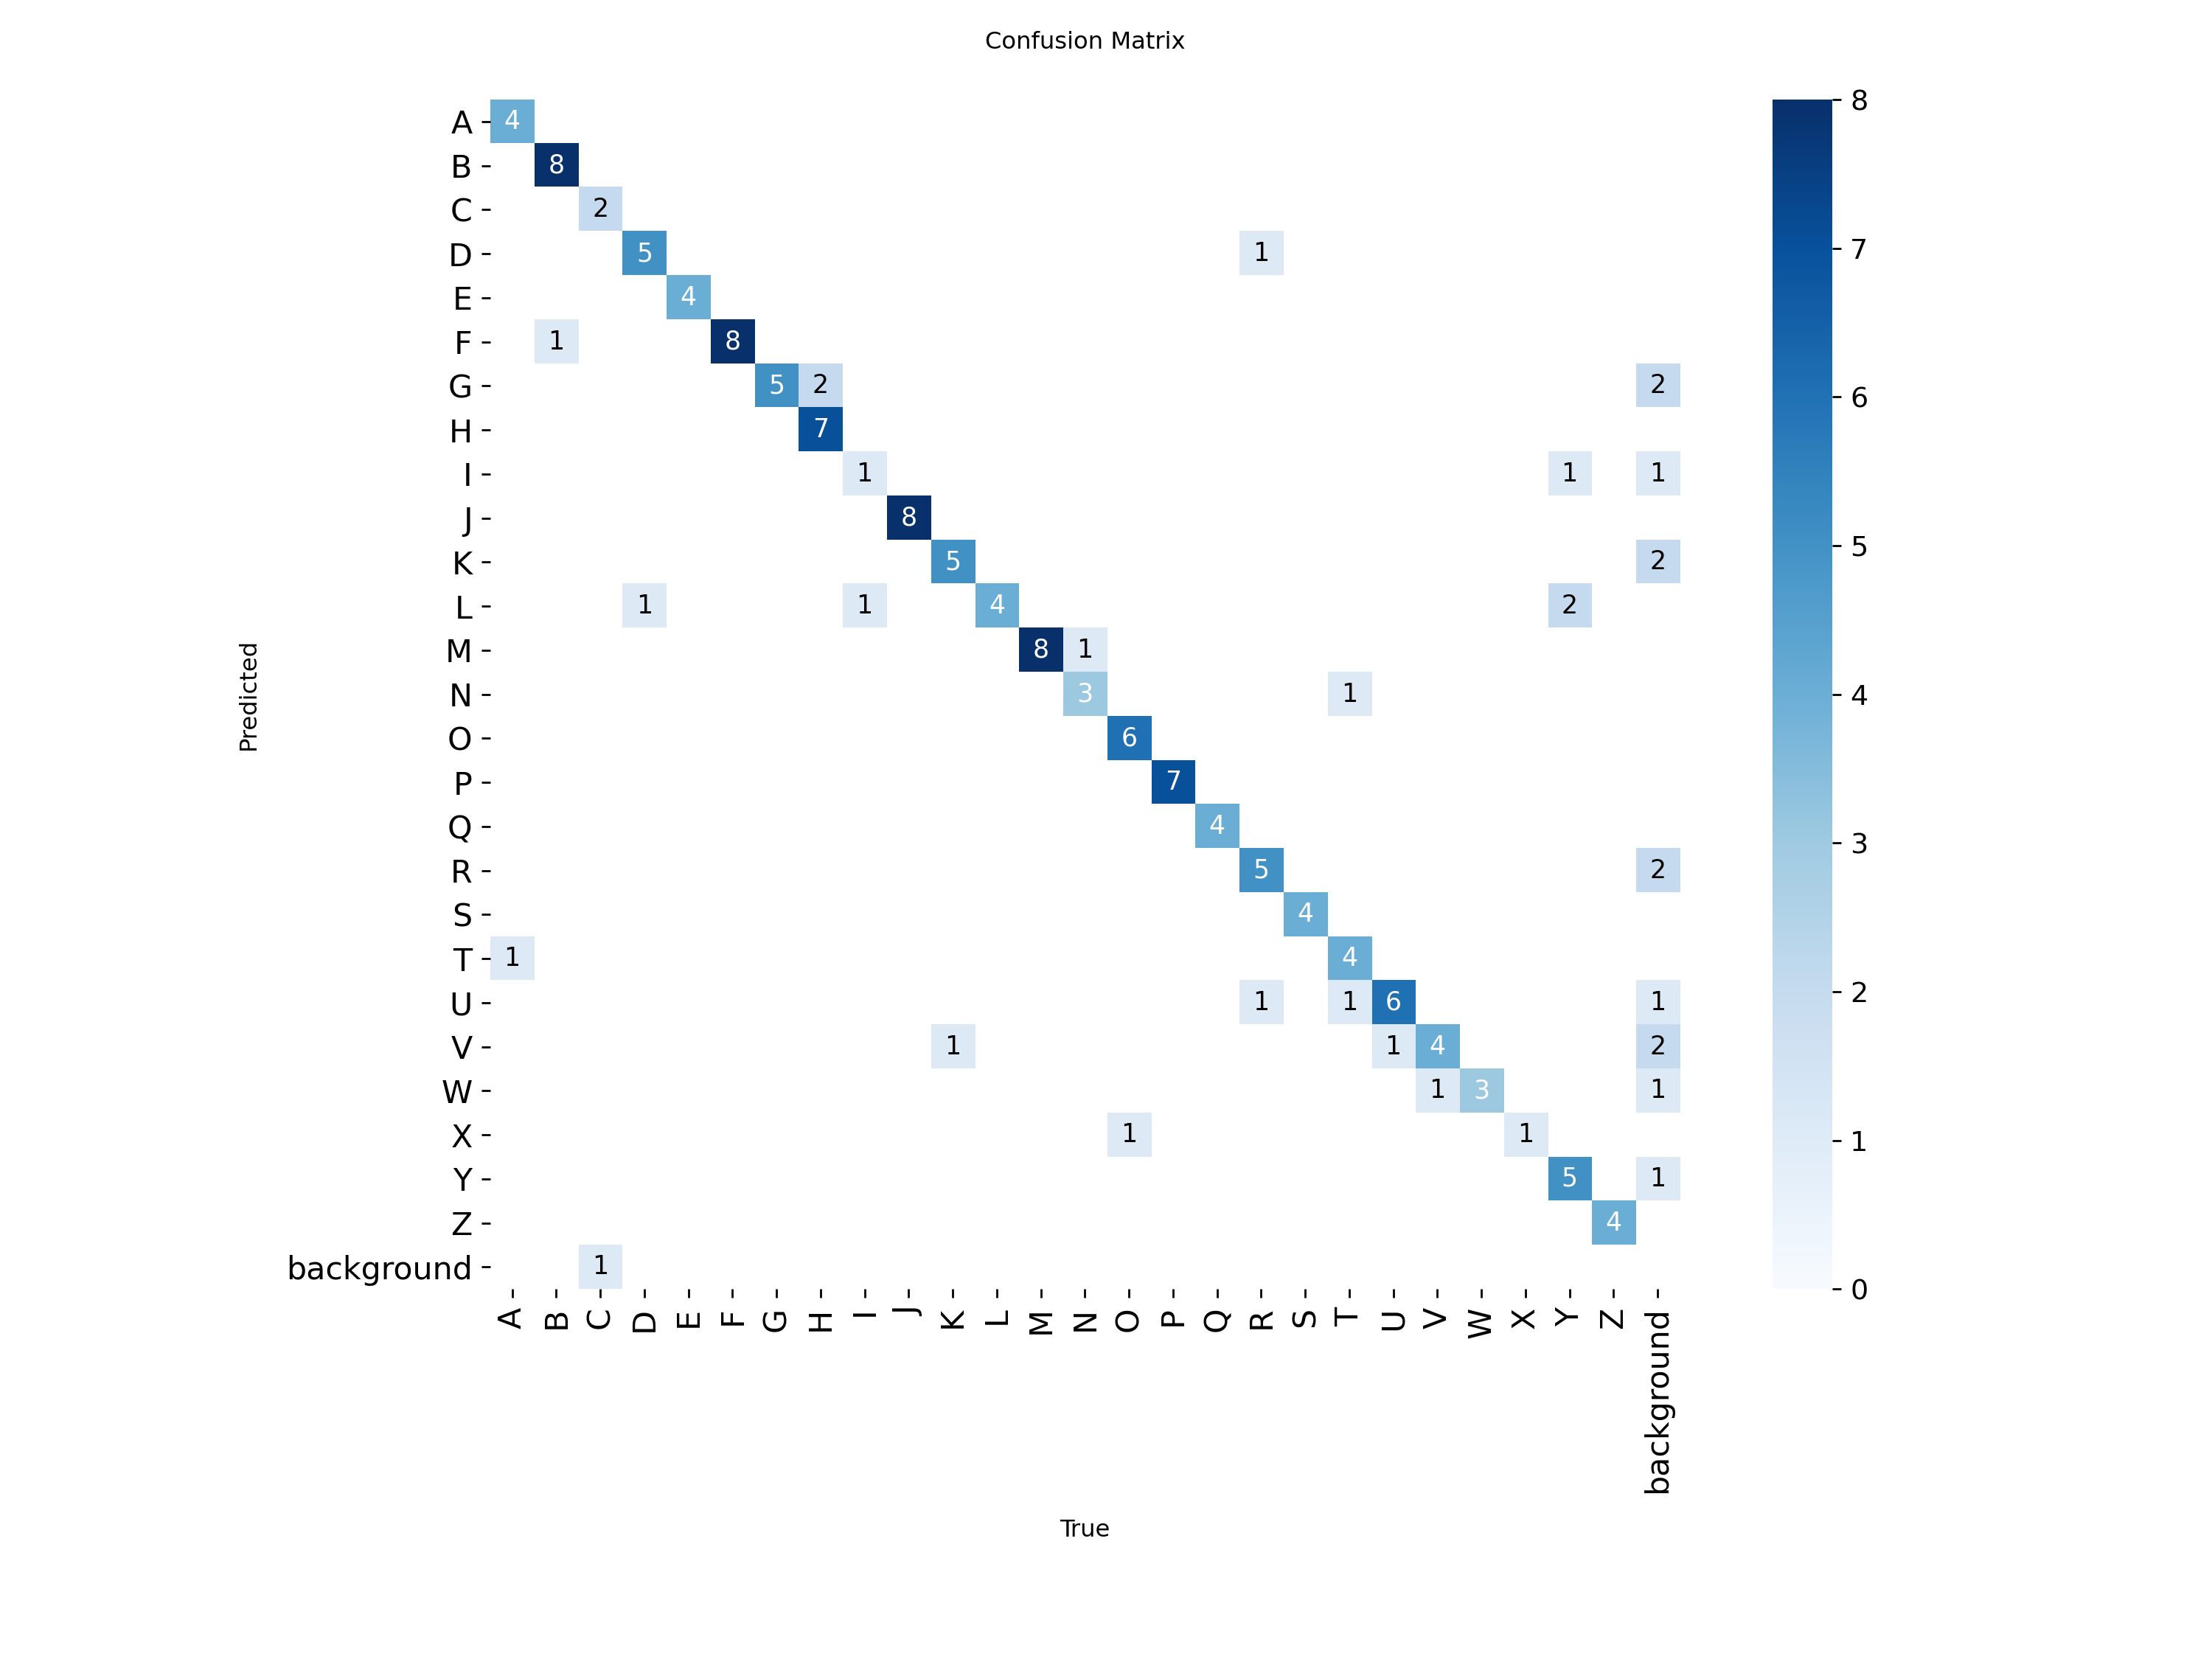

In [11]:
Image("/content/runs/detect/train/confusion_matrix.png", width=600)

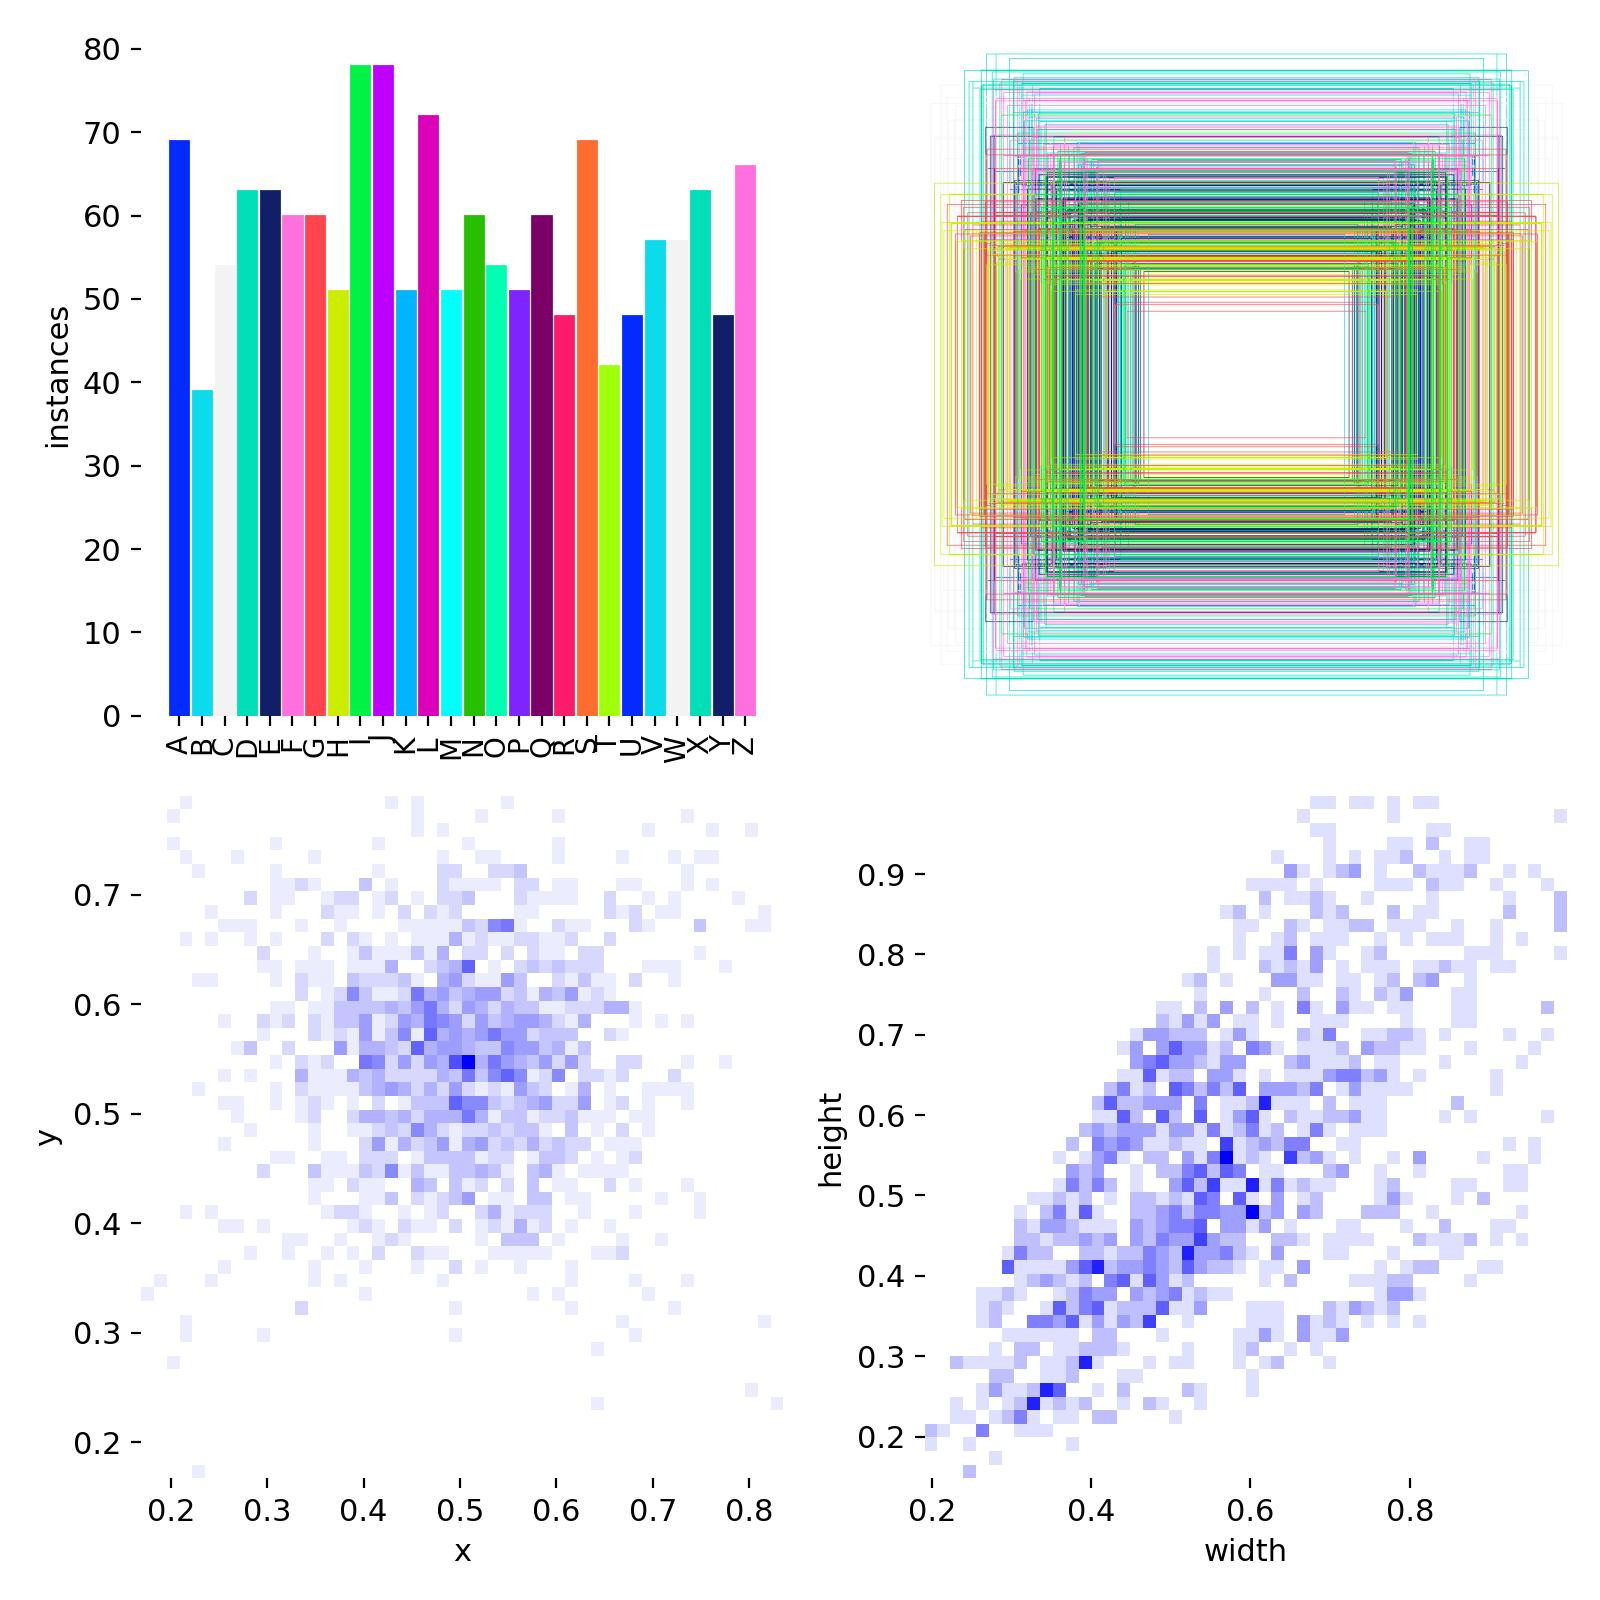

In [12]:
Image("/content/runs/detect/train/labels.jpg", width=600)

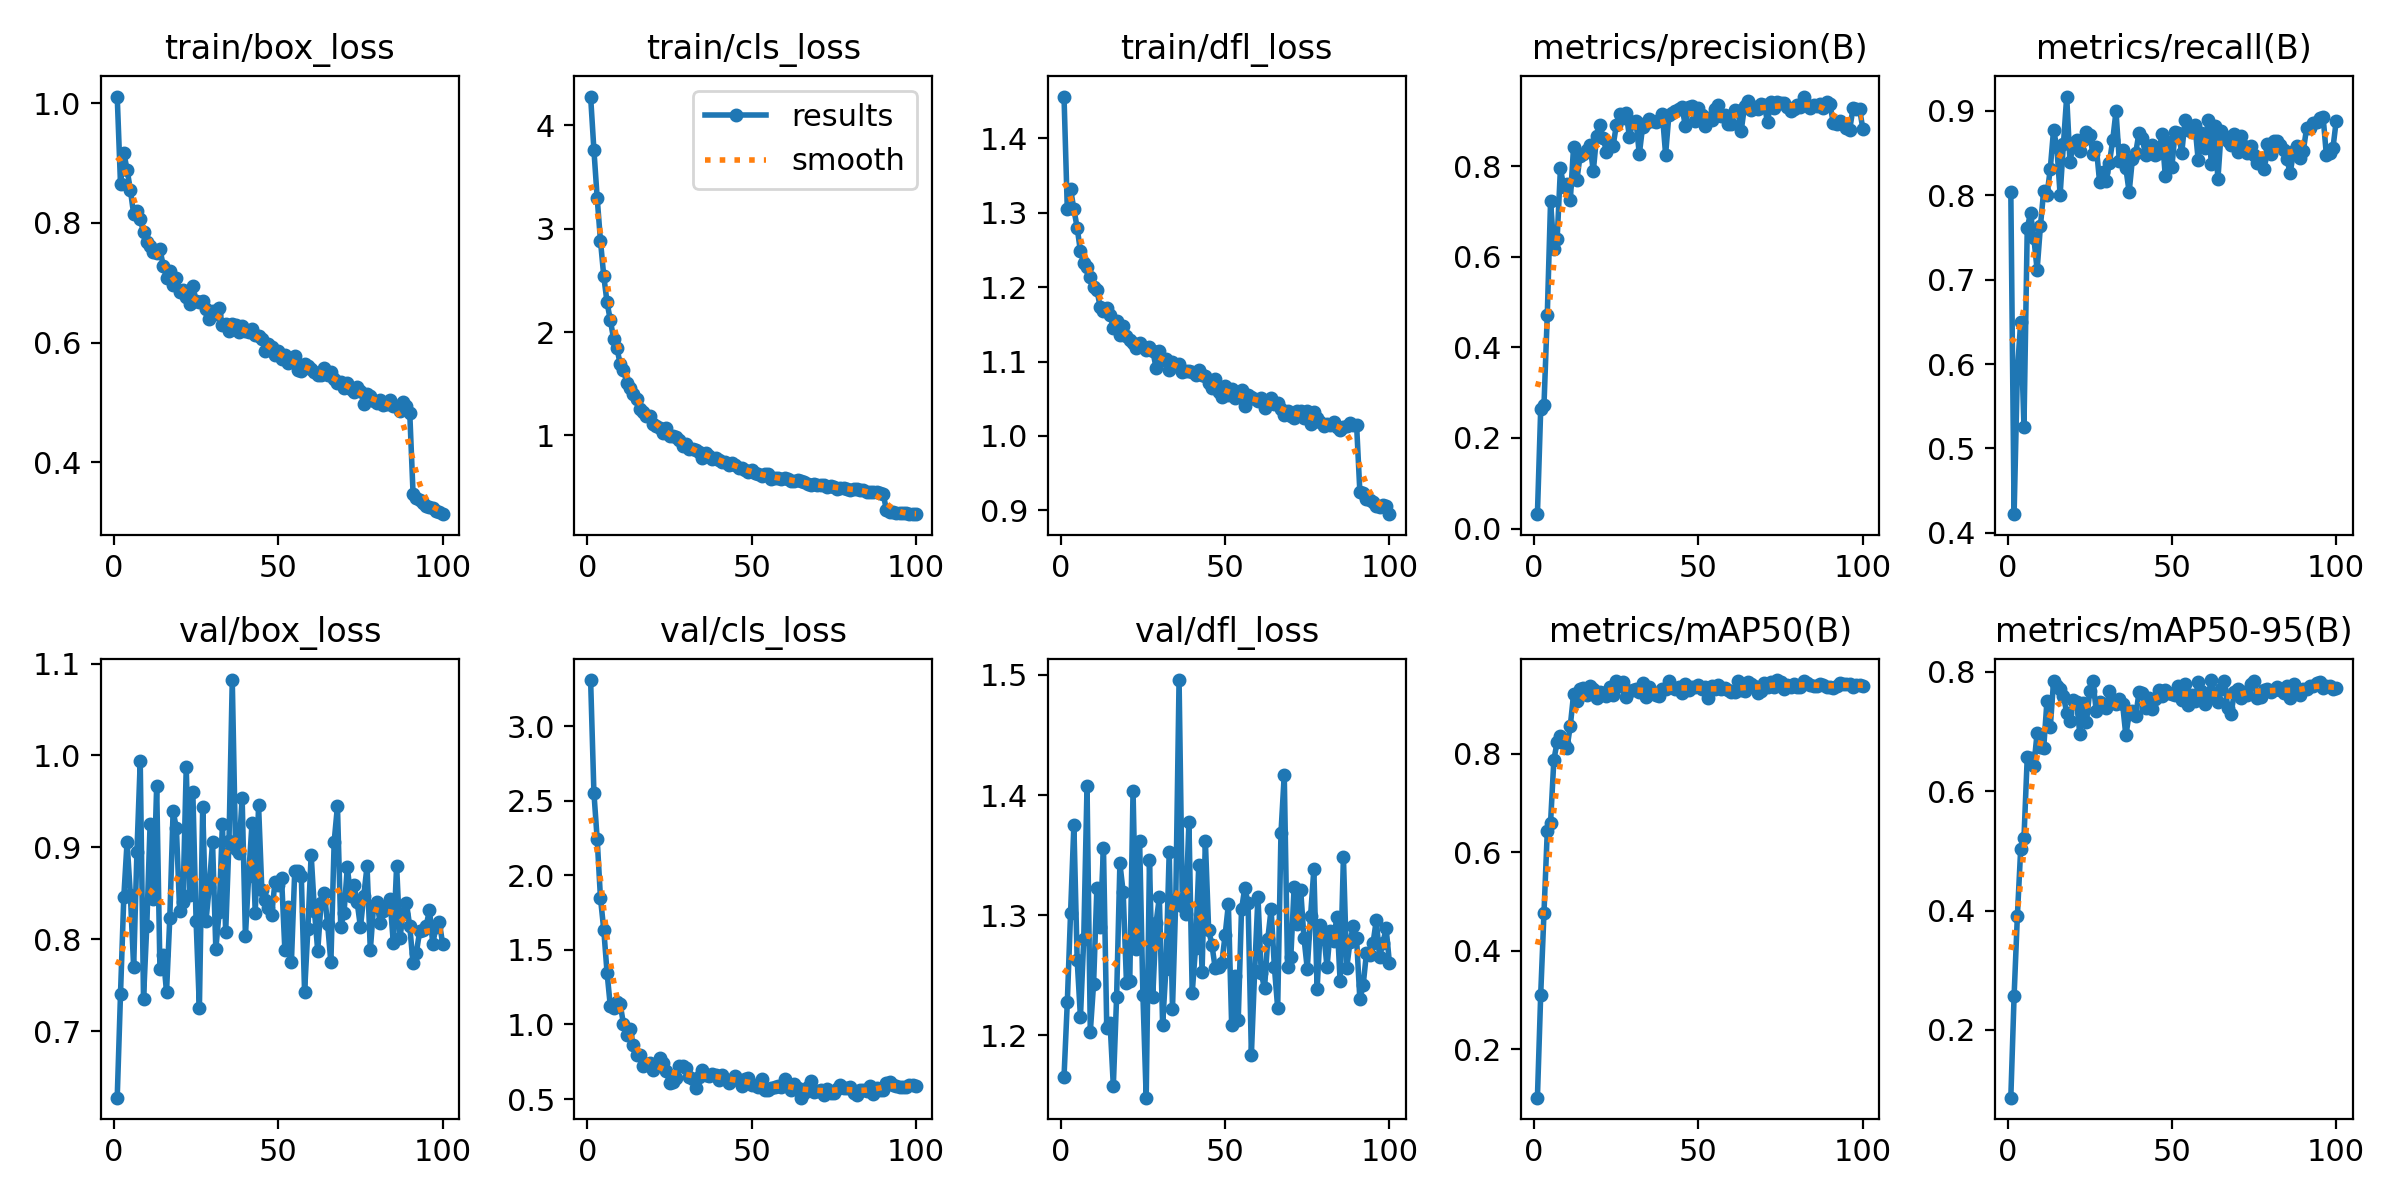

In [13]:
Image("/content/runs/detect/train/results.png", width=600)

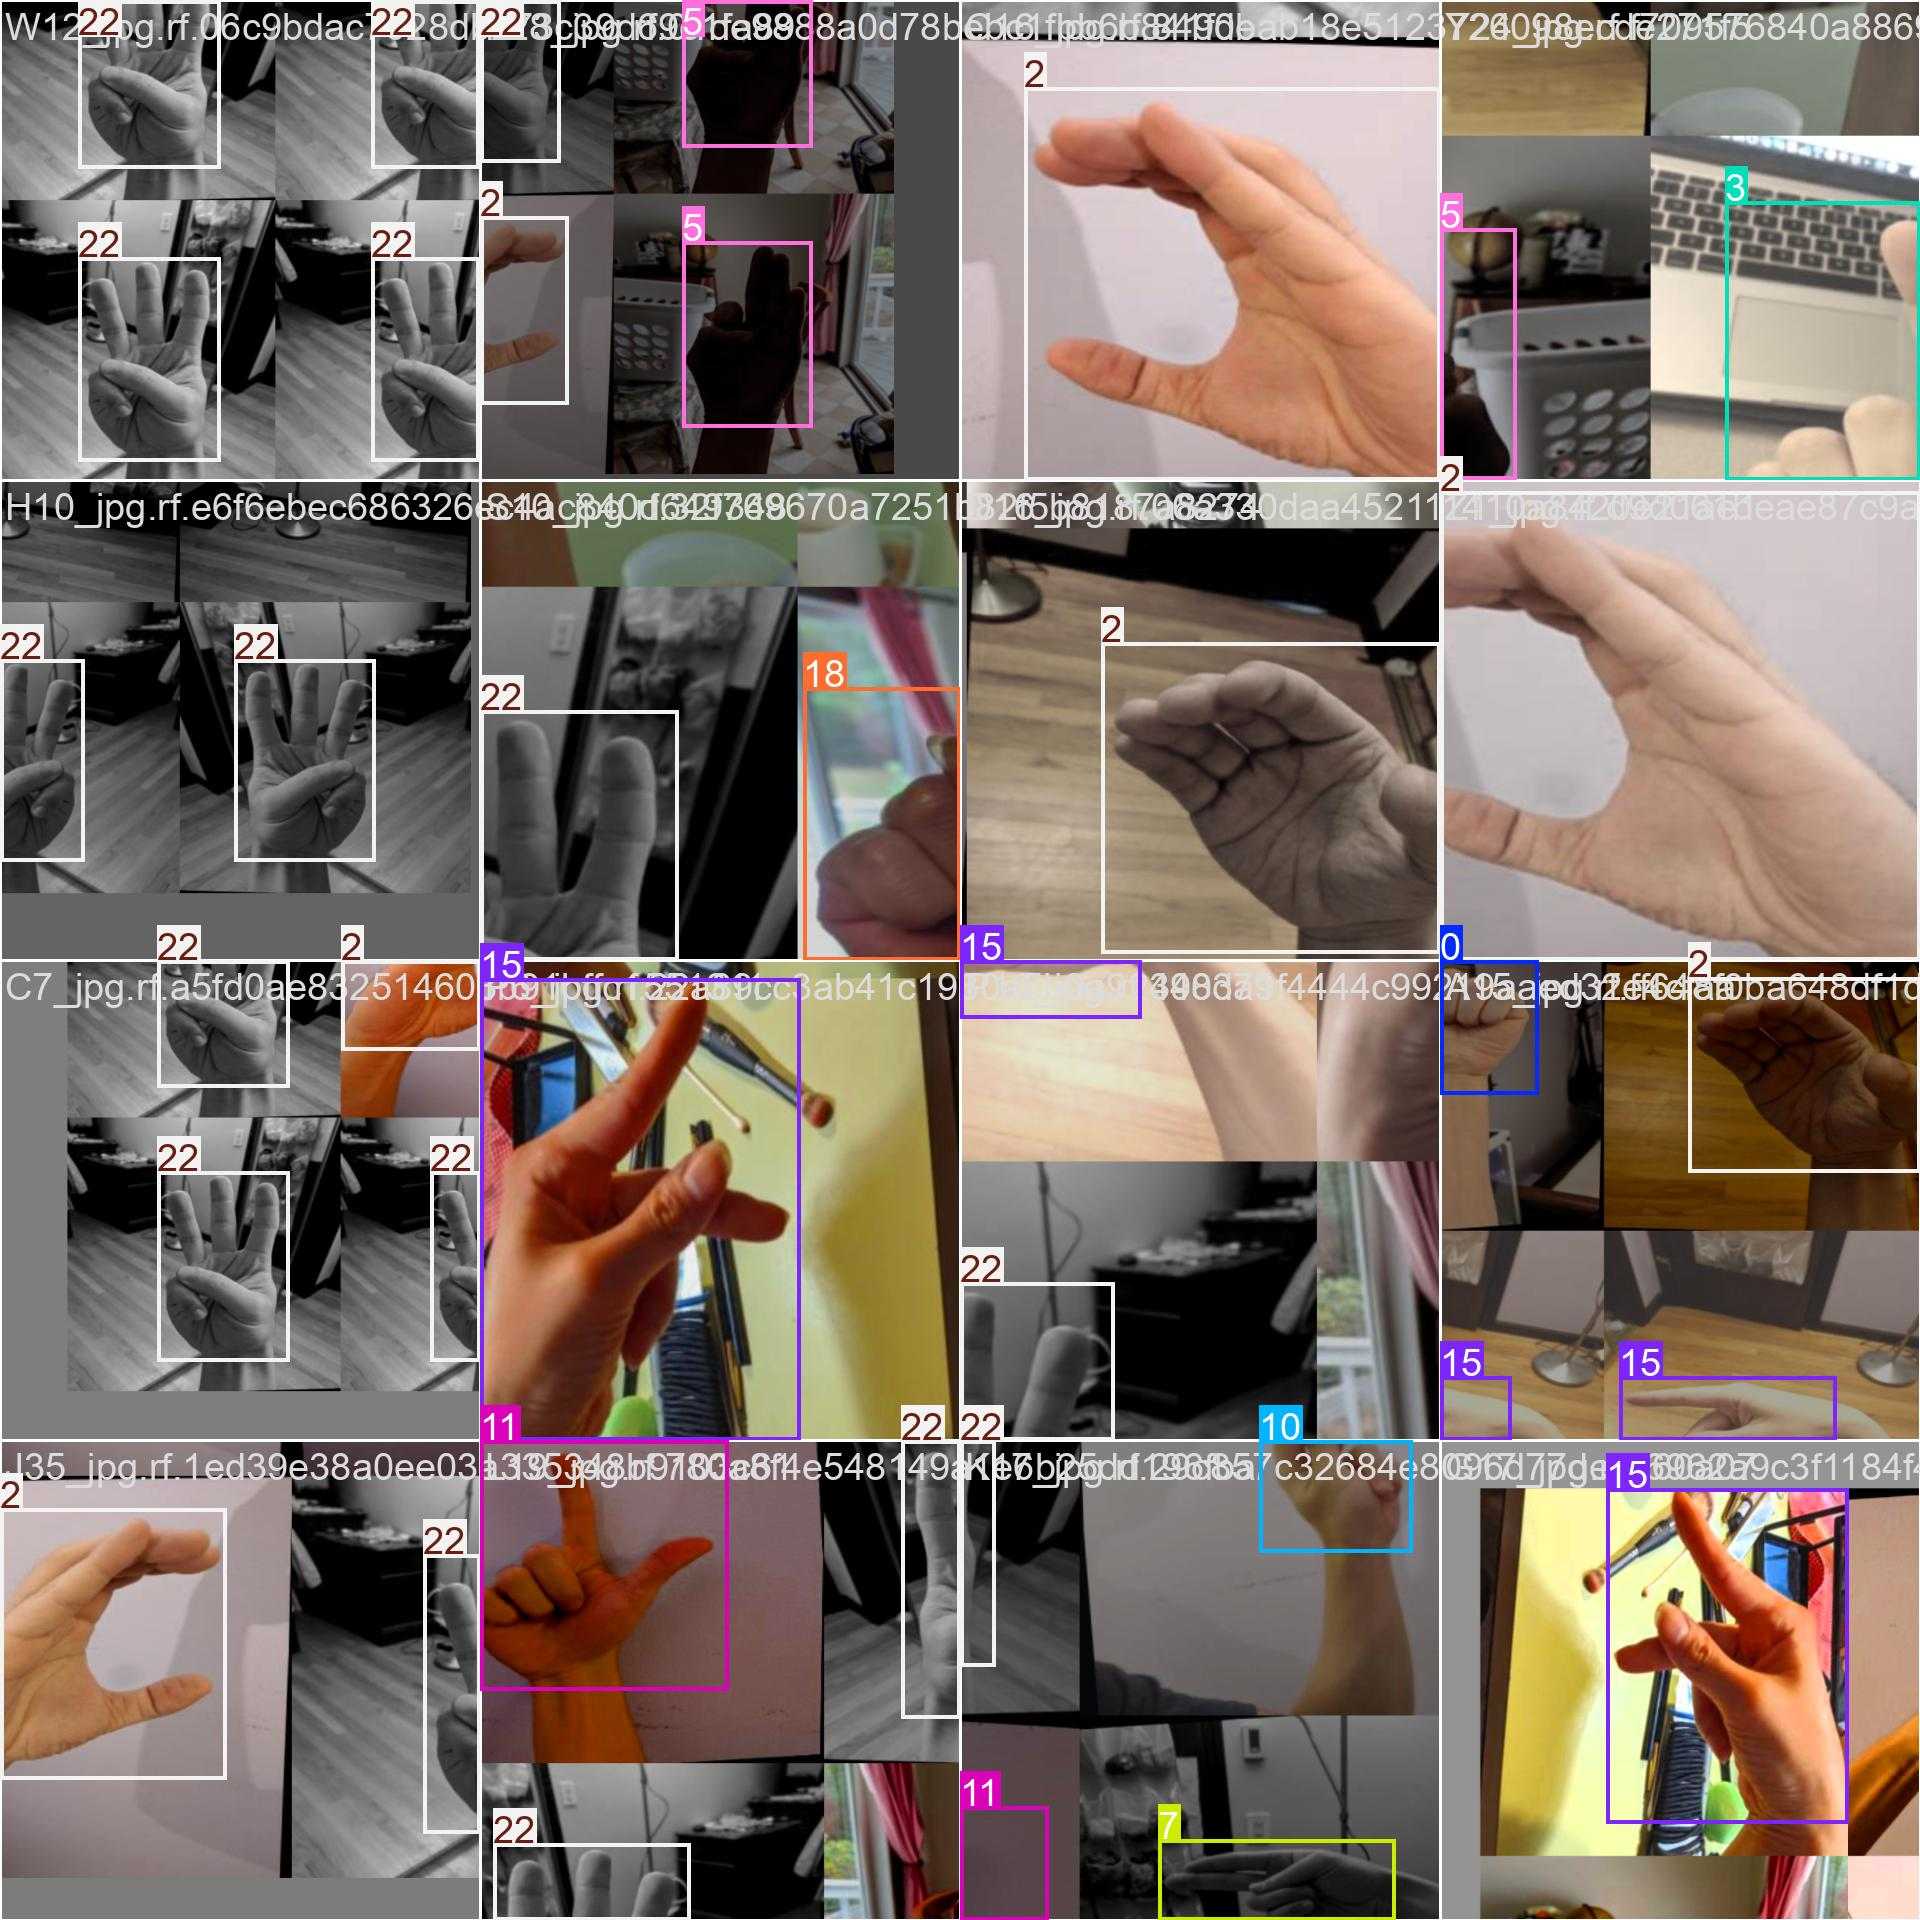

In [14]:
Image("/content/runs/detect/train/train_batch0.jpg", width=600)

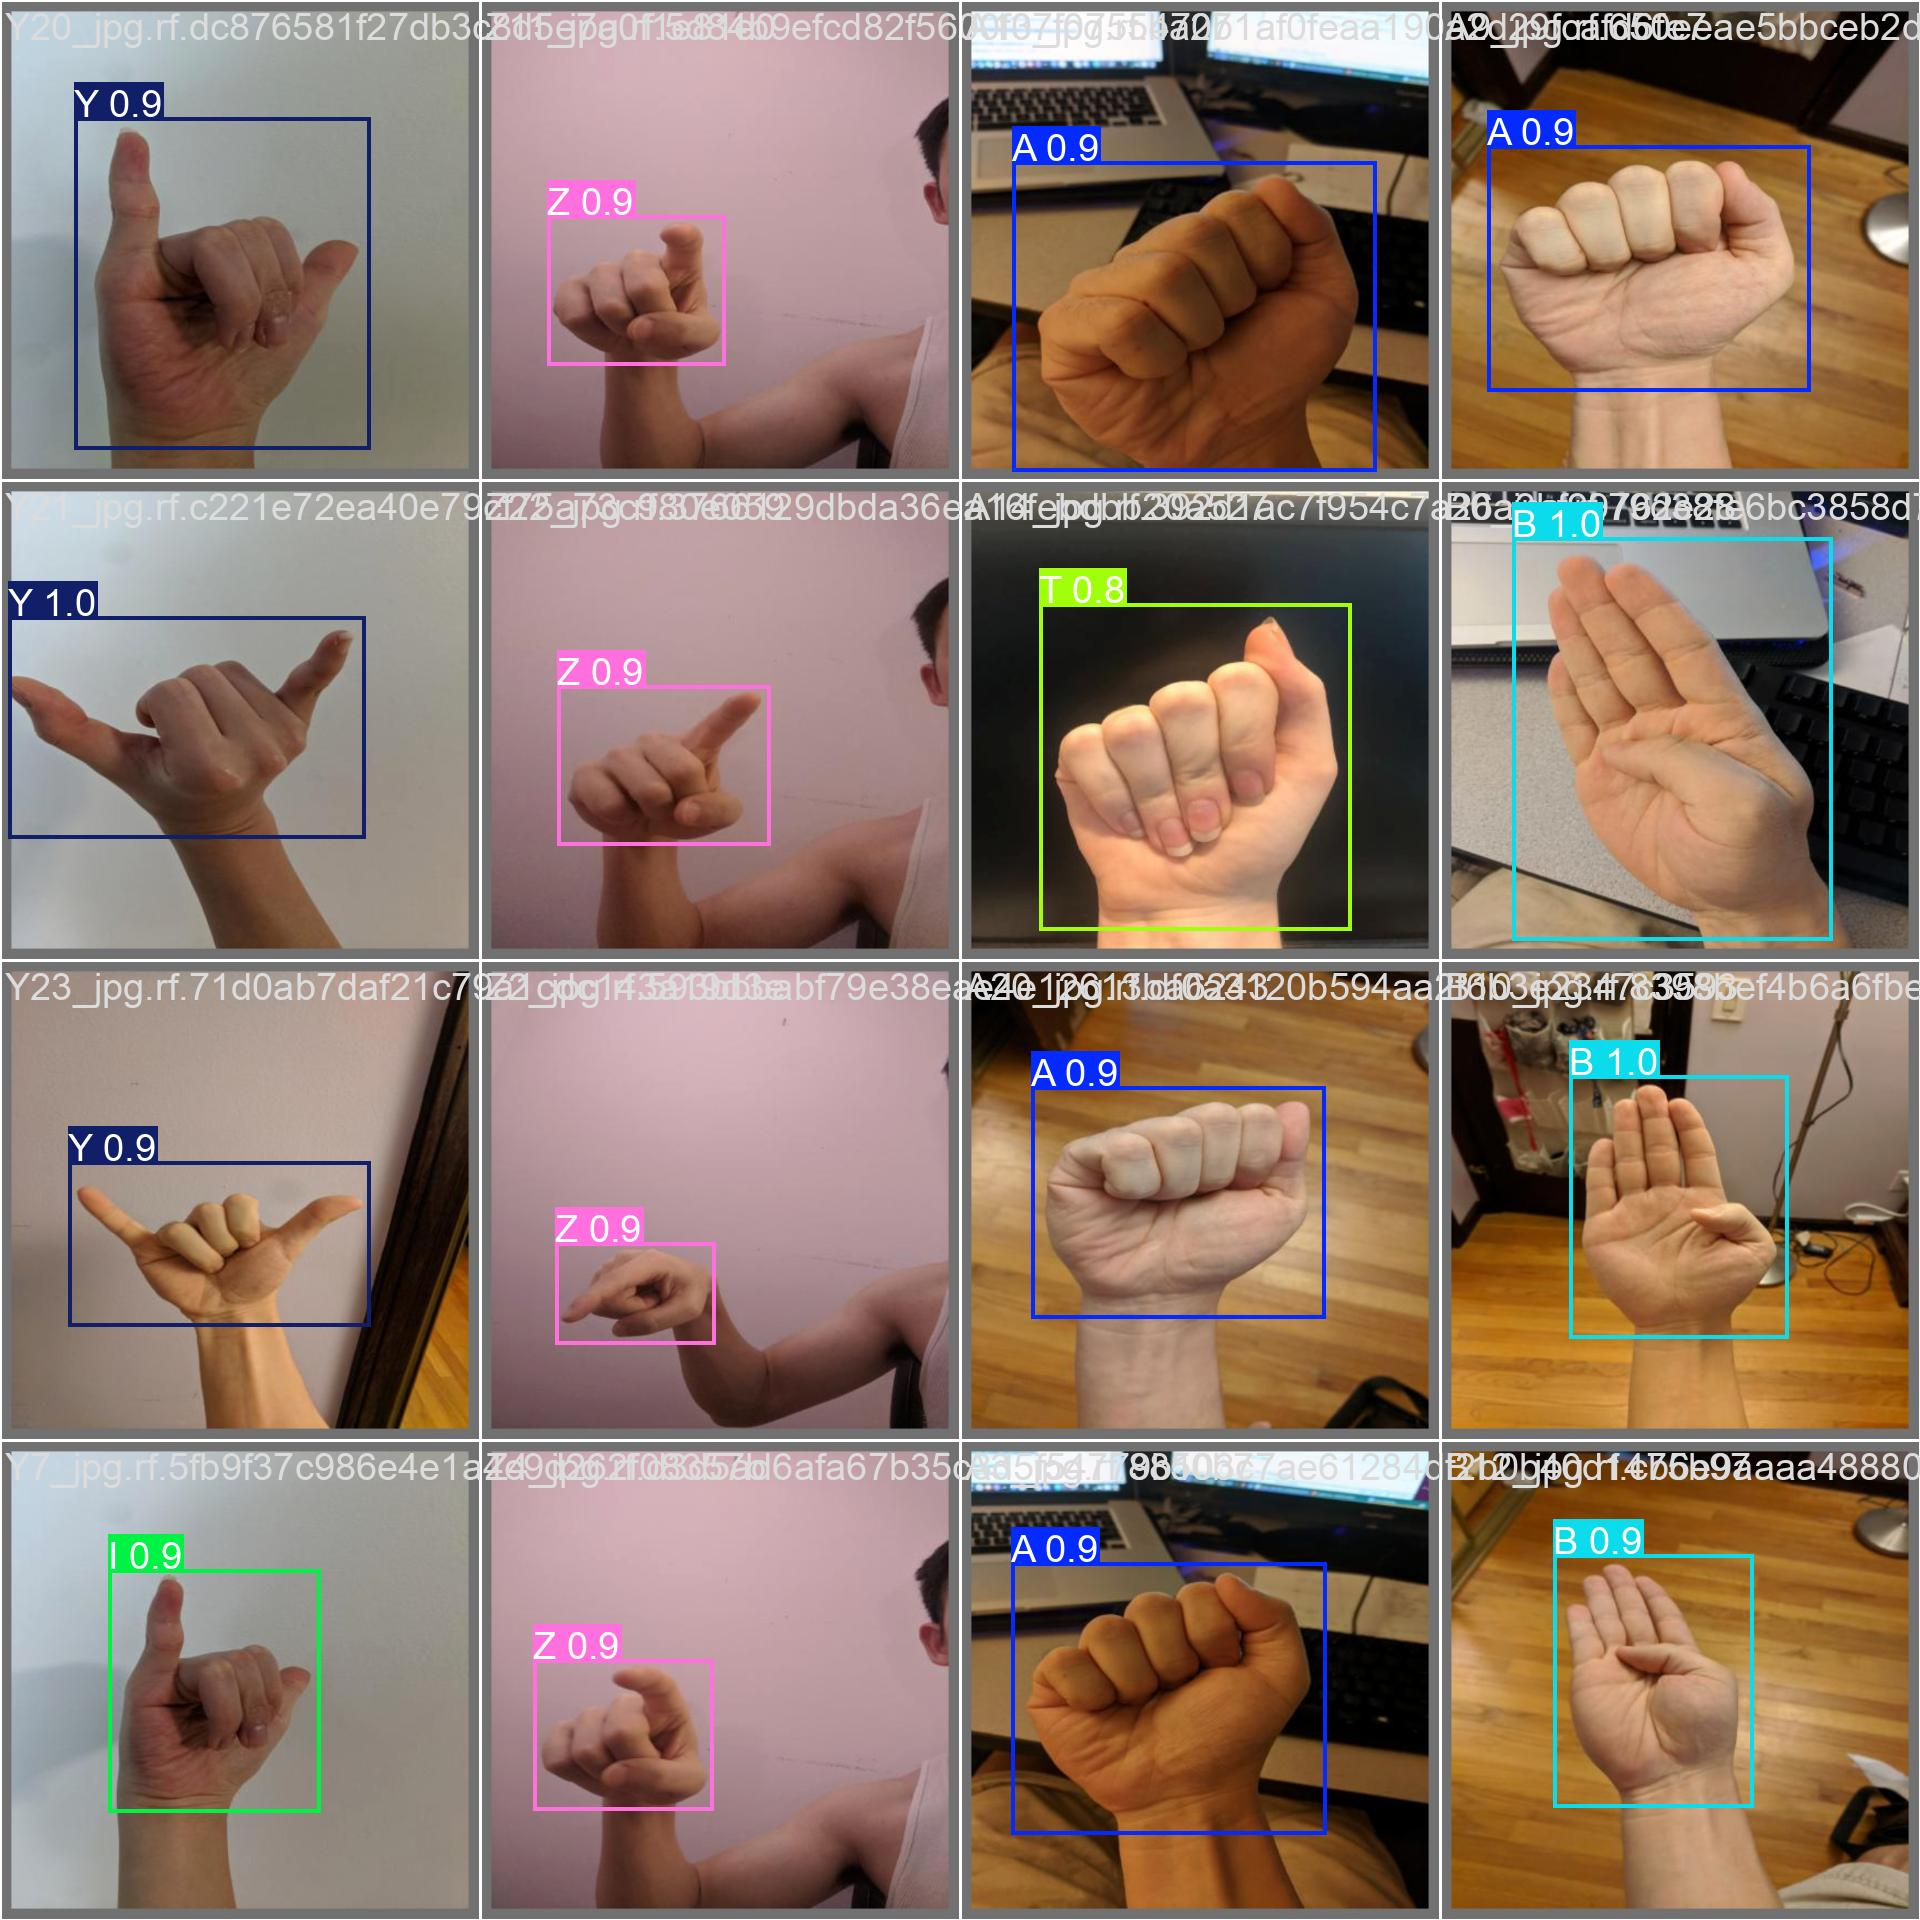

In [15]:
Image("/content/runs/detect/train/val_batch0_pred.jpg", width=600)

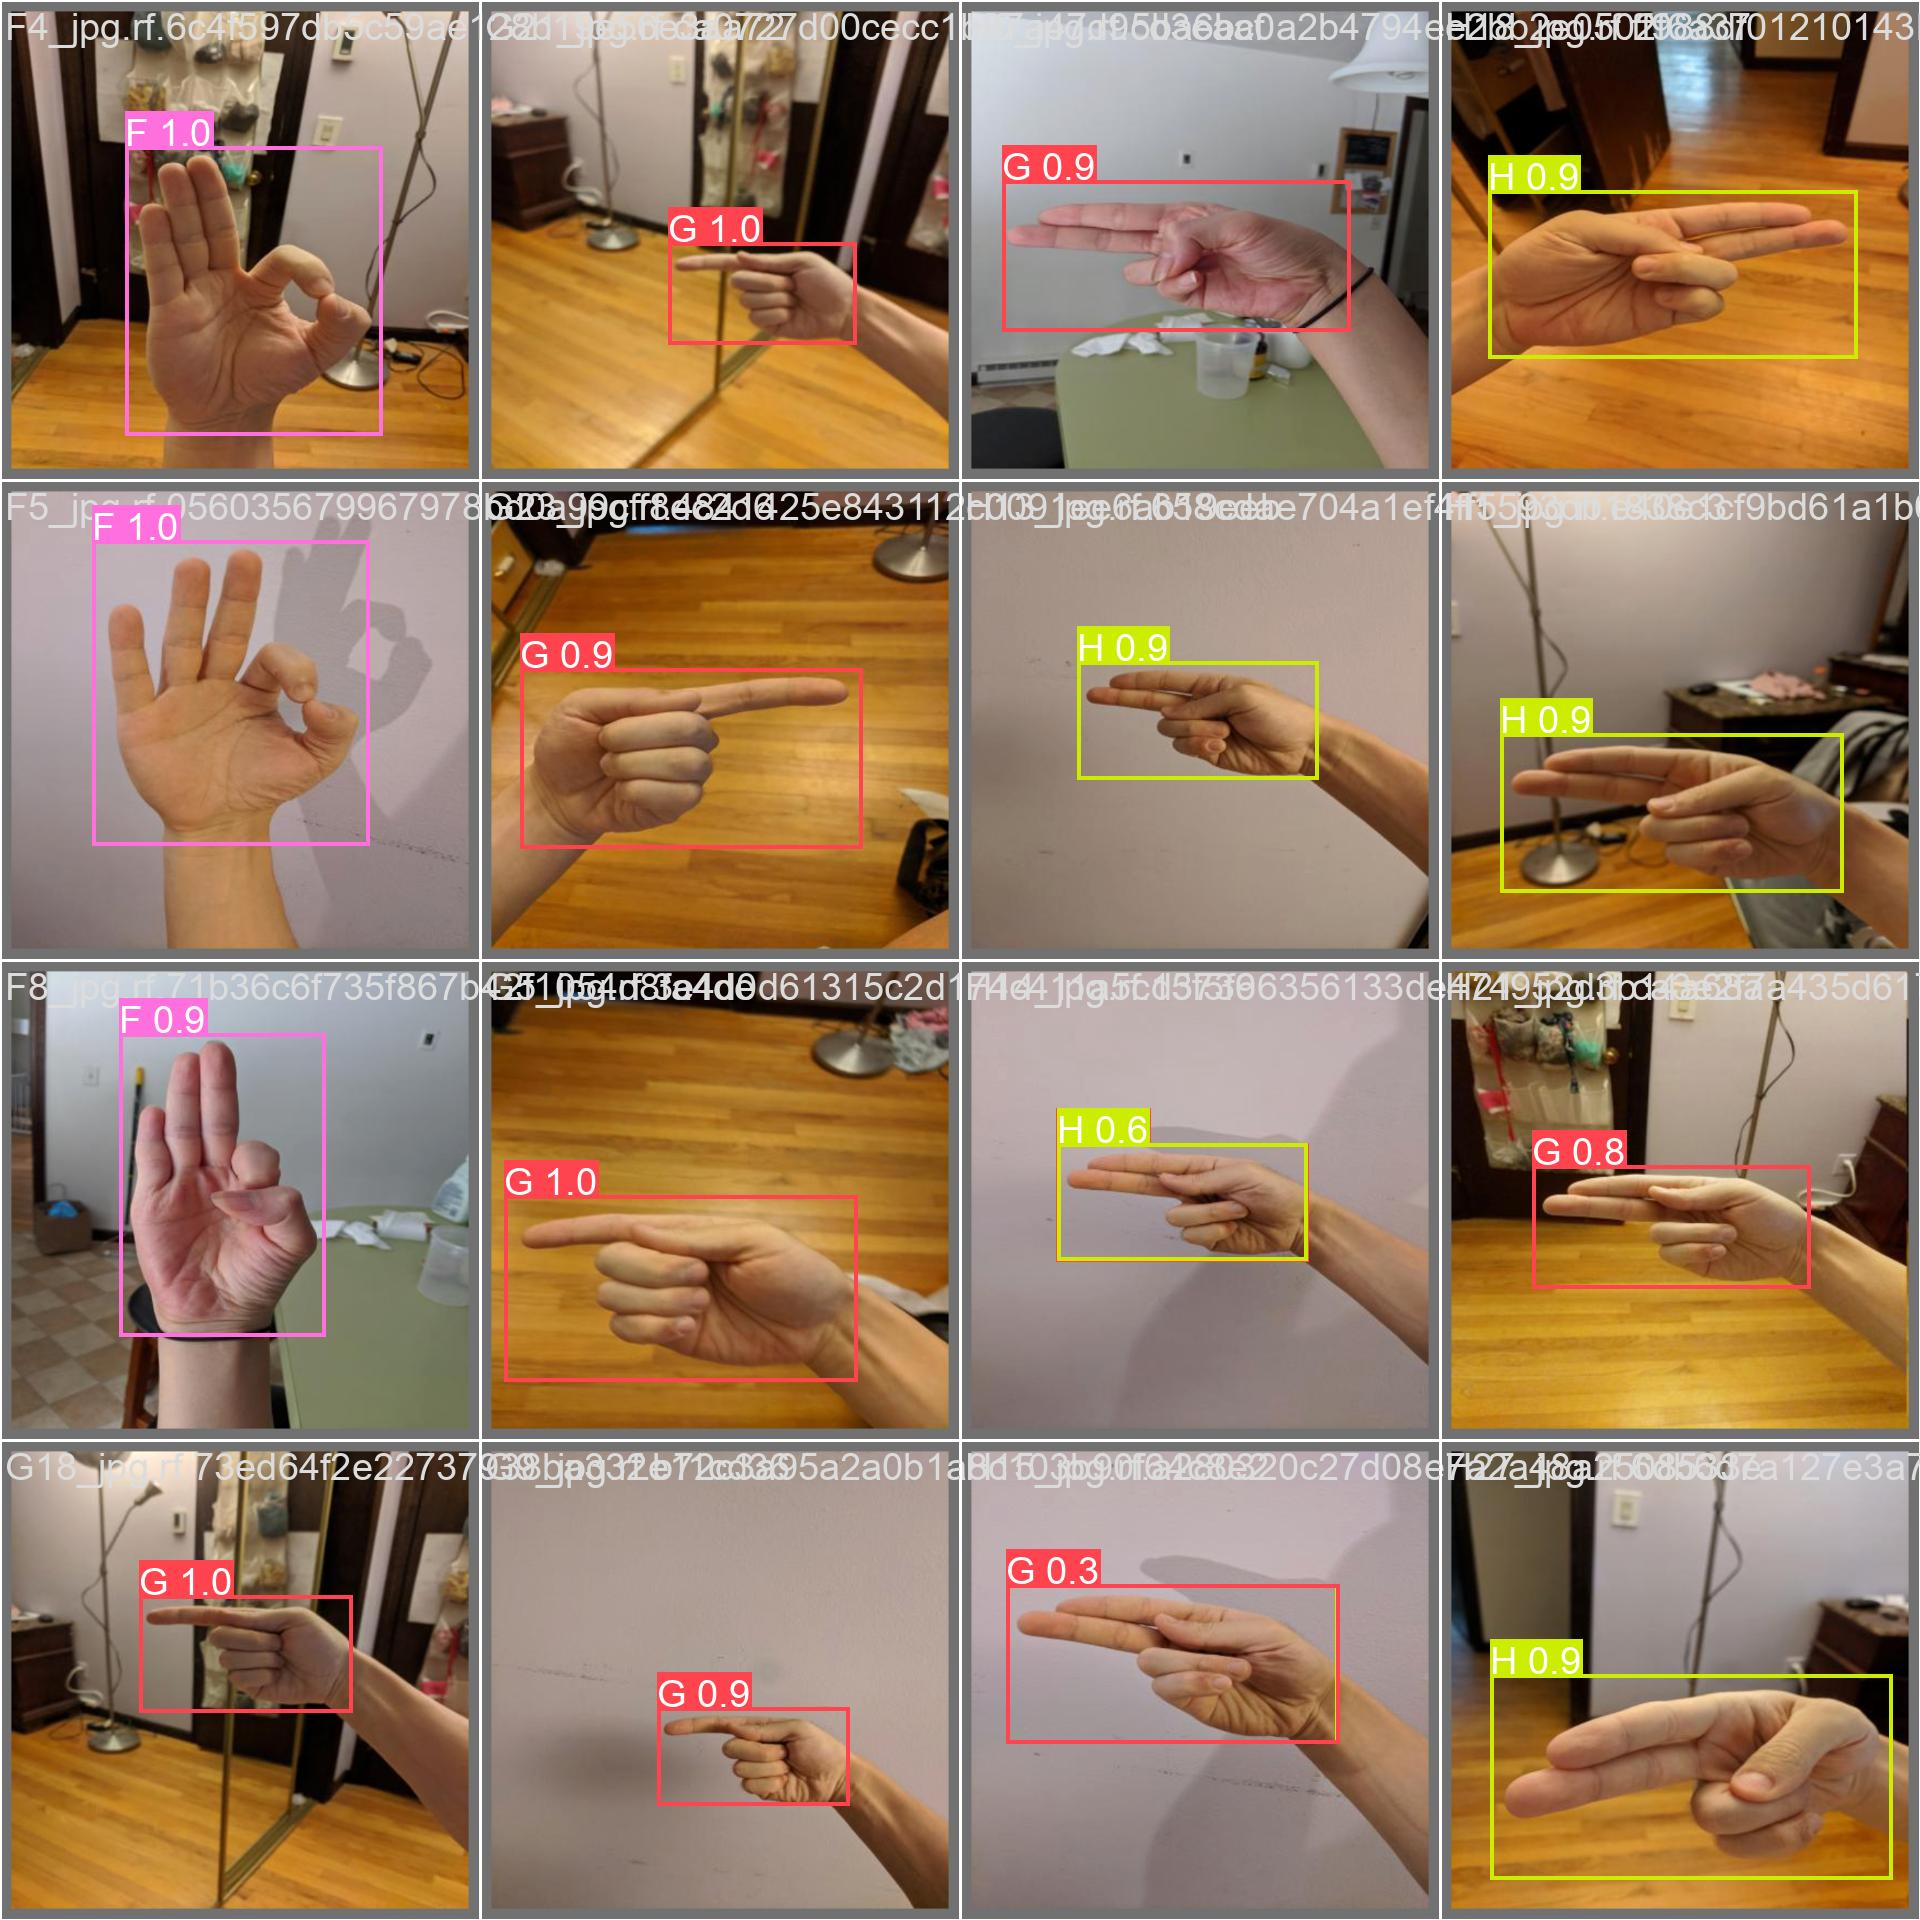

In [16]:
Image("/content/runs/detect/train/val_batch1_pred.jpg", width=600)

**Step # 07  Validate Fine-Tuned Model**

In [18]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset_location}/data.yaml

Ultralytics 8.3.145 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 703.4±148.3 MB/s, size: 19.4 KB)
val: Scanning /content/asl_dataset/valid/labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% 144/144 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 9/9 [00:02<00:00,  3.39it/s]
                   all        144        144       0.92      0.838      0.948      0.786
                     A          5          5      0.989        0.8      0.962        0.8
                     B          9          9          1      0.823      0.984      0.799
                     C          3          3      0.935      0.667      0.755      0.604
                     D          6          6          1      0.819      0.955      0.835
                     E          4          4      0.979  

**Step # 08 Inference with Custom Model on Images**

In [19]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source={dataset_location}/test/images save=True

Ultralytics 8.3.145 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs

image 1/72 /content/asl_dataset/test/images/A22_jpg.rf.f02ad8558ce1c88213b4f83c0bc66bc8.jpg: 640x640 1 A, 18.3ms
image 2/72 /content/asl_dataset/test/images/B14_jpg.rf.ed5ba6d44f55ab03e62d2baeac4aa1aa.jpg: 640x640 1 B, 9.2ms
image 3/72 /content/asl_dataset/test/images/B15_jpg.rf.0f0628552139144fc67c453e1f1b7b15.jpg: 640x640 1 B, 8.2ms
image 4/72 /content/asl_dataset/test/images/B19_jpg.rf.69527cc1f34d694cc04e55db80ed9b1a.jpg: 640x640 1 B, 8.3ms
image 5/72 /content/asl_dataset/test/images/C17_jpg.rf.ceb81f8ae3c3673bd060ebe71848eca8.jpg: 640x640 1 C, 8.4ms
image 6/72 /content/asl_dataset/test/images/C19_jpg.rf.577ce02a223c65e89dc4a4eacd130040.jpg: 640x640 1 C, 8.4ms
image 7/72 /content/asl_dataset/test/images/C22_jpg.rf.e54cbbfdd4ea0670eb4e1c507de4a8a2.jpg: 640x640 1 C, 8.0ms
image 8/72 /content/asl_dataset/test/images/C23_

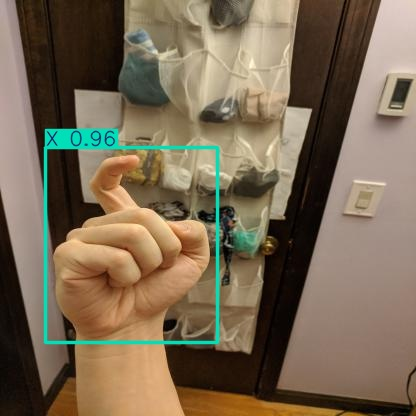

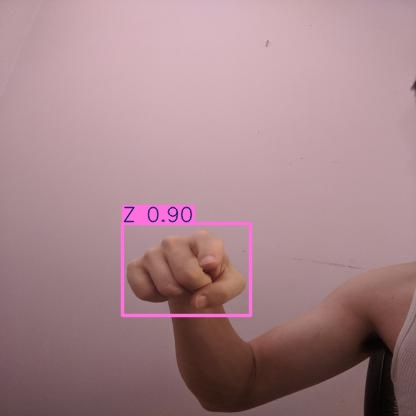

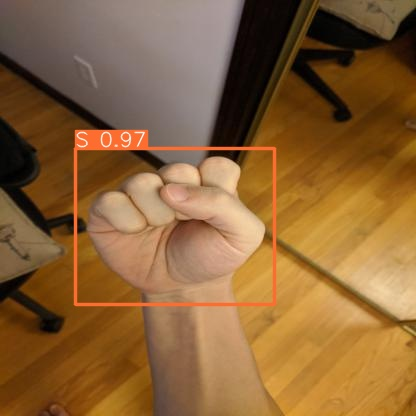

In [20]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [23]:
!yolo task=detect mode=predict model= "/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/asl_dataset/test/images/B14_jpg.rf.ed5ba6d44f55ab03e62d2baeac4aa1aa.jpg save=True

Ultralytics 8.3.145 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/asl_dataset/test/images/B14_jpg.rf.ed5ba6d44f55ab03e62d2baeac4aa1aa.jpg: 640x640 1 B, 12.9ms
Speed: 4.6ms preprocess, 12.9ms inference, 137.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


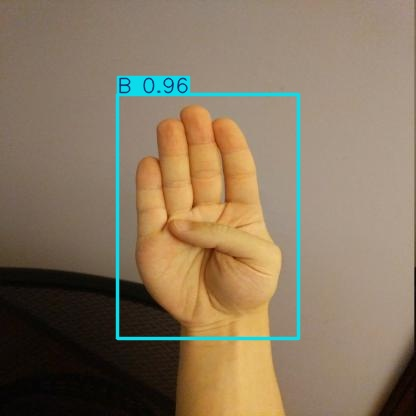

In [24]:
Image("/content/runs/detect/predict3/B14_jpg.rf.ed5ba6d44f55ab03e62d2baeac4aa1aa.jpg", width=600)

In [25]:
!yolo task=detect mode=predict model= "/content/runs/detect/train/weights/best.pt" conf=0.25 source=/content/asl_dataset/test/images/C17_jpg.rf.ceb81f8ae3c3673bd060ebe71848eca8.jpg save=True

Ultralytics 8.3.145 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/asl_dataset/test/images/C17_jpg.rf.ceb81f8ae3c3673bd060ebe71848eca8.jpg: 640x640 1 C, 13.5ms
Speed: 3.9ms preprocess, 13.5ms inference, 132.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


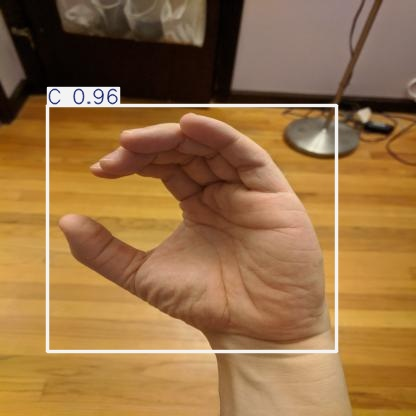

In [26]:
Image("/content/runs/detect/predict4/C17_jpg.rf.ceb81f8ae3c3673bd060ebe71848eca8.jpg", width=600)

**Step # 08 Inference with Custom Model on Videos**

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = '/content/runs/detect/predict3/PPE_Part1.avi'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)